# Problem 7: Loan Default Prediction with Google TabFM

## Problem
A bank needs to determine whether an applicant is likely to default on a loan.

## What to do
Classify applicants as likely to **repay** or **default**.

## Goals
- Reduce credit risk
- Approve more reliable borrowers
- Price loans appropriately

Target: `Default / No Default`

This notebook provides a production-style workflow: direct web download, leakage-safe preprocessing, baseline + TabFM model comparison, threshold optimization, and artifact persistence.

## 0) Why this design

### Dataset
We use OpenML **GiveMeSomeCredit** dataset (`data_id=46929`) and download it directly from web inside the notebook.
Target: `FinancialDistressNextTwoYears` (1 = default, 0 = no default).

### Feature alignment
Available fields cover key credit-risk patterns:
- Income: `MonthlyIncome`
- Existing debt burden: `DebtRatio`
- Credit utilization: `RevolvingUtilizationOfUnsecuredLines`
- Previous repayment behavior: delinquency count features
- Household stability proxy: `NumberOfDependents`

### Caveat
Direct employment-history and explicit loan-amount columns are not present in this dataset. We add proxy features and document assumptions explicitly.

## 1) Reproducible setup

Optional environment variables:

- `TABFM_DEVICE=auto|cpu|cuda`
- `OPENML_DATA_ID=46929`
- `LOAN_SAMPLE_TRAIN_ROWS=80000` (0 means full)
- `LOAN_SAMPLE_EVAL_ROWS=30000` (0 means full)
- `LOAN_MIN_SAMPLE_ROWS=2000`
- `TABFM_CONTEXT_MAX_ROWS=2500`
- `TABFM_EVAL_MAX_ROWS=3000` (0 means full val/test model ranking)
- `TABFM_FAST_MODE=0|1`
- `TABFM_CHECKPOINT_PATH=/abs/path/to/classification/pytorch_model.bin_or_repo_root` (optional)

License note:
- TabFM code is Apache-2.0.
- TabFM released weights are non-commercial; review terms before commercial use.

In [1]:
from __future__ import annotations

import json
import os
import random
import time
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import torch
from loguru import logger
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.datasets import fetch_openml
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

from tabfm import TabFMClassifier
from tabfm import tabfm_v1_0_0_pytorch as tabfm_v1_0_0

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

TABFM_DEVICE_PREF = os.getenv('TABFM_DEVICE', 'auto').lower().strip()
if TABFM_DEVICE_PREF not in {'auto', 'cpu', 'cuda'}:
    raise ValueError(f'Unsupported TABFM_DEVICE={TABFM_DEVICE_PREF}')

OPENML_DATA_ID = int(os.getenv('OPENML_DATA_ID', '46929'))
SAMPLE_TRAIN_ROWS = int(os.getenv('LOAN_SAMPLE_TRAIN_ROWS', '80000'))
SAMPLE_EVAL_ROWS = int(os.getenv('LOAN_SAMPLE_EVAL_ROWS', '30000'))
MIN_SAMPLE_ROWS = int(os.getenv('LOAN_MIN_SAMPLE_ROWS', '2000'))
TABFM_CONTEXT_MAX_ROWS = int(os.getenv('TABFM_CONTEXT_MAX_ROWS', '2500'))
TABFM_EVAL_MAX_ROWS = int(os.getenv('TABFM_EVAL_MAX_ROWS', '3000'))
TABFM_FAST_MODE = os.getenv('TABFM_FAST_MODE', '0').strip() == '1'
TABFM_CHECKPOINT_OVERRIDE = os.getenv('TABFM_CHECKPOINT_PATH', '').strip()

if SAMPLE_TRAIN_ROWS != 0 and SAMPLE_TRAIN_ROWS <= MIN_SAMPLE_ROWS:
    raise ValueError(f'LOAN_SAMPLE_TRAIN_ROWS must be 0 or > {MIN_SAMPLE_ROWS}')
if SAMPLE_EVAL_ROWS != 0 and SAMPLE_EVAL_ROWS <= MIN_SAMPLE_ROWS:
    raise ValueError(f'LOAN_SAMPLE_EVAL_ROWS must be 0 or > {MIN_SAMPLE_ROWS}')
if TABFM_CONTEXT_MAX_ROWS <= 500:
    raise ValueError('TABFM_CONTEXT_MAX_ROWS must be > 500 for stable TabFM fitting.')
if TABFM_EVAL_MAX_ROWS != 0 and TABFM_EVAL_MAX_ROWS <= 500:
    raise ValueError('TABFM_EVAL_MAX_ROWS must be 0 or > 500.')


def resolve_tabfm_device(preference: str) -> str:
    if preference == 'auto':
        return 'cuda' if torch.cuda.is_available() else 'cpu'
    if preference == 'cuda' and not torch.cuda.is_available():
        logger.warning('TABFM_DEVICE=cuda requested but CUDA unavailable; falling back to cpu')
        return 'cpu'
    return preference


def find_project_root(start: Path) -> Path:
    for cand in [start, *start.parents]:
        if (cand / 'pyproject.toml').exists():
            return cand
    raise RuntimeError('Could not find project root (pyproject.toml not found).')


PROJECT_ROOT = find_project_root(Path.cwd())
PROBLEM_ROOT = PROJECT_ROOT / 'problems' / 'problem7_loan_default_prediction'
DATA_DIR = PROBLEM_ROOT / 'data' / 'raw'
ARTIFACT_DIR = PROBLEM_ROOT / 'artifacts'

DATA_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = resolve_tabfm_device(TABFM_DEVICE_PREF)
TABFM_CKPT_PATH = Path(TABFM_CHECKPOINT_OVERRIDE) if TABFM_CHECKPOINT_OVERRIDE else None

logger.info('Project root: {}', PROJECT_ROOT)
logger.info('Problem root: {}', PROBLEM_ROOT)
logger.info('Raw data dir: {}', DATA_DIR)
logger.info('Artifacts dir: {}', ARTIFACT_DIR)
logger.info('OpenML data id: {}', OPENML_DATA_ID)
logger.info('TabFM device preference={} effective={}', TABFM_DEVICE_PREF, DEVICE)
logger.info('Sample train/eval rows: {}/{} (0 means full)', SAMPLE_TRAIN_ROWS, SAMPLE_EVAL_ROWS)
logger.info('TabFM context max rows: {}', TABFM_CONTEXT_MAX_ROWS)
logger.info('TabFM eval max rows: {} (0 means full)', TABFM_EVAL_MAX_ROWS)
logger.info('TabFM fast mode: {}', TABFM_FAST_MODE)
logger.info('TabFM checkpoint override: {}', TABFM_CKPT_PATH)

sns.set_theme(style='whitegrid')

2026-07-03 04:56:24.793 | INFO     | __main__:<module>:95 - Project root: /home/ahmad/AI/Github/google-tabFM-implementation


2026-07-03 04:56:24.794 | INFO     | __main__:<module>:96 - Problem root: /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem7_loan_default_prediction


2026-07-03 04:56:24.795 | INFO     | __main__:<module>:97 - Raw data dir: /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem7_loan_default_prediction/data/raw


2026-07-03 04:56:24.795 | INFO     | __main__:<module>:98 - Artifacts dir: /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem7_loan_default_prediction/artifacts


2026-07-03 04:56:24.796 | INFO     | __main__:<module>:99 - OpenML data id: 46929


...

2026-07-03 04:56:24.796 | INFO     | __main__:<module>:101 - Sample train/eval rows: 20000/6000 (0 means full)


2026-07-03 04:56:24.797 | INFO     | __main__:<module>:102 - TabFM context max rows: 1200


2026-07-03 04:56:24.797 | INFO     | __main__:<module>:103 - TabFM eval max rows: 800 (0 means full)


2026-07-03 04:56:24.797 | INFO     | __main__:<module>:104 - TabFM fast mode: True


2026-07-03 04:56:24.797 | INFO     | __main__:<module>:105 - TabFM checkpoint override: /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem2_saas_subscription_churn/data/models/google-tabfm-1.0.0-pytorch/classification/pytorch_model.bin


## 2) Download dataset directly from web (OpenML)

In [2]:
CACHE_CSV = DATA_DIR / f'loan_default_openml_{OPENML_DATA_ID}.csv'

if CACHE_CSV.exists():
    df = pd.read_csv(CACHE_CSV)
    logger.info('Loaded cached dataset {} shape={}', CACHE_CSV, df.shape)
else:
    ds = fetch_openml(data_id=OPENML_DATA_ID, as_frame=True, parser='auto')
    X_raw = ds.data.copy()
    y_raw = ds.target.copy()

    df = X_raw.copy()
    df['FinancialDistressNextTwoYears'] = y_raw

    df.to_csv(CACHE_CSV, index=False)
    logger.info('Downloaded OpenML dataset {} (id={}) shape={} and cached at {}', ds.details.get('name'), OPENML_DATA_ID, df.shape, CACHE_CSV)

CACHE_CSV


2026-07-03 04:56:24.876 | INFO     | __main__:<module>:5 - Loaded cached dataset /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem7_loan_default_prediction/data/raw/loan_default_openml_46929.csv shape=(150000, 11)


PosixPath('/home/ahmad/AI/Github/google-tabFM-implementation/problems/problem7_loan_default_prediction/data/raw/loan_default_openml_46929.csv')

## 3) Clean and audit data

In [3]:
TARGET_COL = 'FinancialDistressNextTwoYears'

if TARGET_COL not in df.columns:
    raise ValueError(f'Missing target column: {TARGET_COL}')

# Numeric coercion for feature columns.
for c in df.columns:
    if c != TARGET_COL:
        df[c] = pd.to_numeric(df[c], errors='coerce')


def normalize_binary_target(series: pd.Series) -> pd.Series:
    if pd.api.types.is_bool_dtype(series):
        return series.astype('int64')

    s = series.copy()

    # Try direct numeric first (already 0/1 labels).
    numeric = pd.to_numeric(s, errors='coerce')
    mapped = pd.Series(np.nan, index=s.index, dtype='float64')
    mapped.loc[numeric.isin([0, 1])] = numeric.loc[numeric.isin([0, 1])]

    # Fill remaining rows from normalized strings.
    remaining = mapped.isna()
    if remaining.any():
        text = s.astype(str).str.strip().str.lower()
        positive = {'1', 'true', 'yes', 'y', 'default', 'bad', 'fraud'}
        negative = {'0', 'false', 'no', 'n', 'no default', 'good', 'legit', 'legitimate'}

        mapped.loc[remaining & text.isin(positive)] = 1.0
        mapped.loc[remaining & text.isin(negative)] = 0.0

    return mapped

raw_target_preview = df[TARGET_COL].astype(str).head(10).tolist()
logger.info('Raw target preview: {}', raw_target_preview)
logger.info('Raw target value counts (top 10): {}', df[TARGET_COL].astype(str).str.lower().value_counts(dropna=False).head(10).to_dict())

df[TARGET_COL] = normalize_binary_target(df[TARGET_COL])

if df[TARGET_COL].notna().sum() == 0:
    raise ValueError('Target normalization produced zero labeled rows; inspect target encoding in source dataset.')

df = df[df[TARGET_COL].notna()].copy()
df[TARGET_COL] = df[TARGET_COL].astype(int)
df = df[df[TARGET_COL].isin([0, 1])].reset_index(drop=True)

if len(df) < 5000:
    raise ValueError(f'Dataset too small after cleaning (rows={len(df)}).')

# Add stable applicant id.
df.insert(0, 'applicant_id', np.arange(len(df), dtype=np.int64))

class_counts = df[TARGET_COL].value_counts().sort_index()
default_rate = float(df[TARGET_COL].mean())

logger.info('Clean shape: {}', df.shape)
logger.info('Class distribution: {}', class_counts.to_dict())
logger.info('Default rate: {:.2%}', default_rate)

pd.DataFrame([
    {'metric': 'rows', 'value': len(df)},
    {'metric': 'columns', 'value': df.shape[1]},
    {'metric': 'default_rate', 'value': default_rate},
    {'metric': 'defaults', 'value': int(class_counts.get(1, 0))},
    {'metric': 'non_defaults', 'value': int(class_counts.get(0, 0))},
])


2026-07-03 04:56:24.887 | INFO     | __main__:<module>:36 - Raw target preview: ['No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No']


2026-07-03 04:56:24.906 | INFO     | __main__:<module>:37 - Raw target value counts (top 10): {'no': 139974, 'yes': 10026}


2026-07-03 04:56:25.024 | INFO     | __main__:<module>:57 - Clean shape: (150000, 12)


2026-07-03 04:56:25.025 | INFO     | __main__:<module>:58 - Class distribution: {0: 139974, 1: 10026}


2026-07-03 04:56:25.026 | INFO     | __main__:<module>:59 - Default rate: 6.68%


,metric,value
0,rows,150000.00000
1,columns,12.00000
2,default_rate,0.06684
3,defaults,10026.00000
4,non_defaults,139974.00000


/tmp/ipykernel_367596/1259358409.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plot_counts.index, y=plot_counts.values, palette='deep')


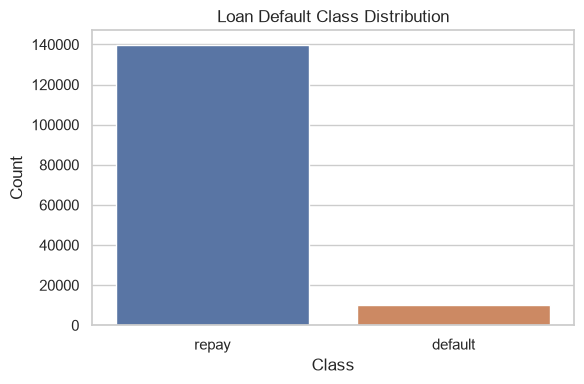

In [4]:
plt.figure(figsize=(6, 4))
plot_counts = df[TARGET_COL].value_counts().rename(index={0: 'repay', 1: 'default'})
sns.barplot(x=plot_counts.index, y=plot_counts.values, palette='deep')
plt.title('Loan Default Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 4) Feature engineering

We derive risk-focused signals:
- delinquency burden aggregates
- utilization and debt-income interactions
- clipped extreme features for stability
- optional income brackets for mixed-type modeling

In [5]:
def engineer_features(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()

    # Rename for convenience.
    if 'SeriousDlqin2yrs' in out.columns and TARGET_COL not in out.columns:
        out[TARGET_COL] = out['SeriousDlqin2yrs']

    # Clip extreme utilization/debt ratio to reduce heavy-tail instability.
    if 'RevolvingUtilizationOfUnsecuredLines' in out.columns:
        out['utilization_clipped'] = out['RevolvingUtilizationOfUnsecuredLines'].clip(lower=0.0, upper=5.0)
    else:
        out['utilization_clipped'] = np.nan

    if 'DebtRatio' in out.columns:
        out['debt_ratio_clipped'] = out['DebtRatio'].clip(lower=0.0, upper=10.0)
    else:
        out['debt_ratio_clipped'] = np.nan

    # Aggregate late-payment features.
    late_cols = [
        'NumberOfTime30-59DaysPastDueNotWorse',
        'NumberOfTime60-89DaysPastDueNotWorse',
        'NumberOfTimes90DaysLate',
    ]
    for c in late_cols:
        if c not in out.columns:
            out[c] = np.nan

    out['late_payment_events_total'] = out[late_cols].sum(axis=1, min_count=1)
    out['late_payment_events_weighted'] = (
        out['NumberOfTime30-59DaysPastDueNotWorse'].fillna(0)
        + 2 * out['NumberOfTime60-89DaysPastDueNotWorse'].fillna(0)
        + 3 * out['NumberOfTimes90DaysLate'].fillna(0)
    )

    # Income transforms and interactions.
    if 'MonthlyIncome' not in out.columns:
        out['MonthlyIncome'] = np.nan

    out['monthly_income_log1p'] = np.log1p(out['MonthlyIncome'].clip(lower=0))
    out['income_x_debt_ratio'] = out['MonthlyIncome'] * out['debt_ratio_clipped']
    out['utilization_x_income'] = out['utilization_clipped'] * out['MonthlyIncome']

    # Household and credit-line burden.
    if 'NumberOfOpenCreditLinesAndLoans' not in out.columns:
        out['NumberOfOpenCreditLinesAndLoans'] = np.nan
    if 'NumberRealEstateLoansOrLines' not in out.columns:
        out['NumberRealEstateLoansOrLines'] = np.nan
    if 'NumberOfDependents' not in out.columns:
        out['NumberOfDependents'] = np.nan

    out['credit_line_burden'] = out['NumberOfOpenCreditLinesAndLoans'] + out['NumberRealEstateLoansOrLines']
    out['dependents_per_income'] = out['NumberOfDependents'] / np.maximum(out['MonthlyIncome'], 1.0)

    # Categorical brackets for model diversity.
    out['income_bracket'] = pd.cut(
        out['MonthlyIncome'],
        bins=[-1, 2500, 5000, 10000, 20000, np.inf],
        labels=['very_low', 'low', 'mid', 'high', 'very_high'],
    ).astype(object)

    out['age_bracket'] = pd.cut(
        out['age'],
        bins=[0, 25, 35, 50, 65, np.inf],
        labels=['18-25', '26-35', '36-50', '51-65', '65+'],
    ).astype(object)

    return out


feature_df = engineer_features(df)
feature_df[[
    'applicant_id',
    'MonthlyIncome',
    'debt_ratio_clipped',
    'late_payment_events_total',
    'credit_line_burden',
    TARGET_COL,
]].head()

,applicant_id,MonthlyIncome,debt_ratio_clipped,late_payment_events_total,credit_line_burden,FinancialDistressNextTwoYears
0,0,10121.0,0.283244,0,8,0
1,1,7750.0,0.142562,0,10,0
2,2,6000.0,0.236294,0,8,0
3,3,4958.0,0.163138,0,4,0
4,4,NaN,10.000000,0,11,0


## 5) Train/validation/test split + class-preserving row caps

In [6]:
META_COLS = ['applicant_id', TARGET_COL, 'MonthlyIncome']


def cap_split_rows(df_split: pd.DataFrame, max_rows: int, seed: int, target_col: str, min_pos: int = 200) -> pd.DataFrame:
    if max_rows == 0 or len(df_split) <= max_rows:
        return df_split.sample(frac=1.0, random_state=seed).reset_index(drop=True)

    pos = df_split[df_split[target_col] == 1]
    neg = df_split[df_split[target_col] == 0]

    if len(pos) == 0:
        return df_split.sample(n=max_rows, random_state=seed).reset_index(drop=True)

    desired_pos = min(len(pos), max(min_pos, int(round(max_rows * len(pos) / len(df_split)))))
    desired_pos = min(desired_pos, max_rows - 1)
    desired_neg = max_rows - desired_pos

    pos_sample = pos.sample(n=desired_pos, random_state=seed)
    neg_sample = neg.sample(n=desired_neg, random_state=seed)

    return pd.concat([pos_sample, neg_sample], axis=0).sample(frac=1.0, random_state=seed).reset_index(drop=True)


train_full, holdout = train_test_split(
    feature_df,
    test_size=0.30,
    random_state=SEED,
    stratify=feature_df[TARGET_COL],
)
val_full, test_full = train_test_split(
    holdout,
    test_size=0.50,
    random_state=SEED,
    stratify=holdout[TARGET_COL],
)

train_df = cap_split_rows(train_full, SAMPLE_TRAIN_ROWS, seed=SEED + 1, target_col=TARGET_COL)
val_df = cap_split_rows(val_full, SAMPLE_EVAL_ROWS, seed=SEED + 2, target_col=TARGET_COL)
test_df = cap_split_rows(test_full, SAMPLE_EVAL_ROWS, seed=SEED + 3, target_col=TARGET_COL)

pd.DataFrame([
    {
        'split': 'train',
        'rows': len(train_df),
        'defaults': int(train_df[TARGET_COL].sum()),
        'default_rate': float(train_df[TARGET_COL].mean()),
    },
    {
        'split': 'val',
        'rows': len(val_df),
        'defaults': int(val_df[TARGET_COL].sum()),
        'default_rate': float(val_df[TARGET_COL].mean()),
    },
    {
        'split': 'test',
        'rows': len(test_df),
        'defaults': int(test_df[TARGET_COL].sum()),
        'default_rate': float(test_df[TARGET_COL].mean()),
    },
])

,split,rows,defaults,default_rate
0,train,20000,1337,0.066850
1,val,6000,401,0.066833
2,test,6000,401,0.066833


## 6) Modeling helpers and XGBoost baseline

In [7]:
def evaluate_classifier(y_true: np.ndarray, y_score: np.ndarray, threshold: float = 0.5) -> dict[str, float]:
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    y_pred = (y_score >= threshold).astype(int)

    return {
        'roc_auc': float(roc_auc_score(y_true, y_score)),
        'pr_auc': float(average_precision_score(y_true, y_score)),
        'brier': float(brier_score_loss(y_true, y_score)),
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'f1': float(f1_score(y_true, y_pred, zero_division=0)),
    }


def make_model_xy(frame: pd.DataFrame) -> tuple[pd.DataFrame, np.ndarray, pd.DataFrame]:
    y = frame[TARGET_COL].to_numpy(dtype=np.int32)
    meta = frame[[c for c in META_COLS if c in frame.columns]].reset_index(drop=True)

    X = frame.drop(columns=[TARGET_COL]).copy()

    if 'applicant_id' in X.columns:
        X = X.drop(columns=['applicant_id'])

    X = X.where(pd.notna(X), np.nan)

    non_numeric_cols = [c for c in X.columns if not pd.api.types.is_numeric_dtype(X[c])]
    for col in non_numeric_cols:
        X[col] = X[col].astype(object)

    return X, y, meta


X_train, y_train, train_meta = make_model_xy(train_df)
X_val, y_val, val_meta = make_model_xy(val_df)
X_test, y_test, test_meta = make_model_xy(test_df)

num_cols = [c for c in X_train.columns if pd.api.types.is_numeric_dtype(X_train[c])]
cat_cols = [c for c in X_train.columns if c not in num_cols]

logger.info('Feature columns total={} num={} cat={}', len(X_train.columns), len(num_cols), len(cat_cols))


def train_xgboost_baseline(X: pd.DataFrame, y: np.ndarray) -> Pipeline:
    n_pos = int((y == 1).sum())
    n_neg = int((y == 0).sum())
    scale_pos_weight = max(1.0, n_neg / max(1, n_pos))

    preprocess = ColumnTransformer(
        transformers=[
            ('num', Pipeline([('imputer', SimpleImputer(strategy='median'))]), num_cols),
            ('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore')),
            ]), cat_cols),
        ],
        remainder='drop',
        verbose_feature_names_out=False,
    )

    model = XGBClassifier(
        n_estimators=260,
        learning_rate=0.05,
        max_depth=6,
        min_child_weight=3,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=1.0,
        random_state=SEED,
        eval_metric='aucpr',
        tree_method='hist',
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight,
    )

    pipe = Pipeline([
        ('preprocess', preprocess),
        ('model', model),
    ])
    pipe.fit(X, y)
    return pipe


def get_scores(model: Any, X: pd.DataFrame) -> np.ndarray:
    proba = np.asarray(model.predict_proba(X))
    if proba.ndim != 2 or proba.shape[1] != 2:
        raise ValueError(f'Expected binary predict_proba [N,2], got {proba.shape}')
    return proba[:, 1].astype(float)


t0 = time.time()
xgb_model = train_xgboost_baseline(X_train, y_train)
logger.info('XGBoost training completed in {:.1f}s', time.time() - t0)

2026-07-03 04:56:25.351 | INFO     | __main__:<module>:42 - Feature columns total=21 num=19 cat=2


2026-07-03 04:56:25.689 | INFO     | __main__:<module>:94 - XGBoost training completed in 0.3s


## 7) Robust TabFM classification checkpoint loading

In [8]:
def _candidate_tabfm_paths() -> list[Path]:
    candidates: list[Path] = []

    if TABFM_CKPT_PATH is not None:
        candidates.append(TABFM_CKPT_PATH)

    # Reuse known local checkpoint from previous problem runs.
    known_local = PROJECT_ROOT / 'problems' / 'problem2_saas_subscription_churn' / 'data' / 'models' / 'google-tabfm-1.0.0-pytorch'
    if known_local.exists():
        candidates.append(known_local)

    # Hugging Face snapshot fallbacks.
    hf_root = Path.home() / '.cache' / 'huggingface' / 'hub' / 'models--google--tabfm-1.0.0-pytorch' / 'snapshots'
    if hf_root.exists():
        for snap in sorted(hf_root.iterdir(), reverse=True):
            if not snap.is_dir():
                continue
            if (snap / 'classification' / 'pytorch_model.bin').exists():
                candidates.append(snap)

    # De-dup preserve order.
    out: list[Path] = []
    seen: set[str] = set()
    for c in candidates:
        s = str(c)
        if s not in seen:
            out.append(c)
            seen.add(s)
    return out


def load_tabfm_backbone(device: str) -> Any:
    errors: list[str] = []
    for ckpt in _candidate_tabfm_paths():
        try:
            logger.info('Trying TabFM classification checkpoint at {}', ckpt)
            return tabfm_v1_0_0.load(
                model_type='classification',
                checkpoint_path=str(ckpt),
                device=device,
            )
        except Exception as exc:
            logger.warning('Failed checkpoint {} -> {}', ckpt, exc)
            errors.append(f'{ckpt}: {exc}')

    try:
        logger.info('Trying TabFM default classification cache/download resolution')
        return tabfm_v1_0_0.load(
            model_type='classification',
            checkpoint_path=None,
            device=device,
        )
    except Exception as exc:
        errors.append(f'default: {exc}')
        raise RuntimeError('Unable to load TabFM classification weights. Tried: ' + ' | '.join(errors)) from exc

## 8) Train 3 TabFM variants

In [9]:
def pick_tabfm_device(requested: str) -> str:
    if requested.startswith('cuda') and torch.cuda.is_available():
        total_mem_gb = torch.cuda.get_device_properties(0).total_memory / (1024**3)
        logger.info('Detected GPU memory {:.2f} GiB', total_mem_gb)
        if total_mem_gb < 12:
            logger.warning('GPU memory <12 GiB; forcing CPU for TabFM stability')
            return 'cpu'
    return requested


def fit_tabfm_variants(X: pd.DataFrame, y: np.ndarray, requested_device: str) -> dict[str, TabFMClassifier]:
    device = pick_tabfm_device(requested_device)

    if len(X) > TABFM_CONTEXT_MAX_ROWS:
        X_fit, _, y_fit, _ = train_test_split(
            X,
            y,
            train_size=TABFM_CONTEXT_MAX_ROWS,
            random_state=SEED,
            stratify=y,
        )
        logger.warning('TabFM context capped: {} -> {} rows', len(X), len(X_fit))
    else:
        X_fit, y_fit = X, y

    batch_size = 1 if device == 'cpu' else 2

    if TABFM_FAST_MODE:
        logger.warning('TABFM_FAST_MODE=1 enabled; lightweight TabFM settings active')
        default_estimators = 2
        ensemble_estimators = 2
        advanced_estimators = 2
        advanced_norm_methods = ['none']
        advanced_n_feature_crosses = 0
        advanced_n_svd_features = 0
        advanced_total_svd_pool = 32
        enable_nnls_flag = False
    else:
        default_estimators = 4
        ensemble_estimators = 6
        advanced_estimators = 6
        advanced_norm_methods = ['none', 'power', 'quantile_rtdl']
        advanced_n_feature_crosses = 'sqrt'
        advanced_n_svd_features = 'sqrt'
        advanced_total_svd_pool = 128
        enable_nnls_flag = True

    models: dict[str, TabFMClassifier] = {}

    m_default = TabFMClassifier(
        model=load_tabfm_backbone(device),
        n_estimators=default_estimators,
        batch_size=batch_size,
        random_state=SEED,
        n_feature_crosses=0,
        n_svd_features=0,
        enable_nnls=False,
        binary_calibration_method=None,
        multiclass_calibration_method=None,
        verbose=False,
        num_folds_for_cv=2,
        min_rows_for_single_val_split=100,
    )
    m_default.fit(X_fit, y_fit)
    models['tabfm_default'] = m_default

    m_ensemble = TabFMClassifier.ensemble(
        model=load_tabfm_backbone(device),
        n_estimators=ensemble_estimators,
        batch_size=batch_size,
        random_state=SEED,
        num_folds_for_cv=2,
        min_rows_for_single_val_split=100,
        enable_nnls=enable_nnls_flag,
        binary_calibration_method=None,
        verbose=False,
    )
    m_ensemble.fit(X_fit, y_fit)
    models['tabfm_ensemble_preset'] = m_ensemble

    m_advanced = TabFMClassifier(
        model=load_tabfm_backbone(device),
        n_estimators=advanced_estimators,
        norm_methods=advanced_norm_methods,
        feat_shuffle_method='random',
        class_shift=True,
        permute_categorical=True,
        n_feature_crosses=advanced_n_feature_crosses,
        n_svd_features=advanced_n_svd_features,
        total_svd_pool=advanced_total_svd_pool,
        average_logits=False,
        enable_nnls=enable_nnls_flag,
        nnls_beta=0.75,
        binary_calibration_method=None,
        random_state=SEED,
        batch_size=batch_size,
        num_folds_for_cv=2,
        min_rows_for_single_val_split=100,
        verbose=False,
    )
    m_advanced.fit(X_fit, y_fit)
    models['tabfm_advanced_custom'] = m_advanced

    logger.info('TabFM variants trained on device={}', device)
    return models


t1 = time.time()
tabfm_models = fit_tabfm_variants(X_train, y_train, requested_device=DEVICE)
logger.info('TabFM training completed in {:.1f}s', time.time() - t1)

2026-07-03 04:56:25.703 | INFO     | __main__:pick_tabfm_device:4 - Detected GPU memory 7.62 GiB


2026-07-03 04:56:25.703 | WARNING  | __main__:pick_tabfm_device:6 - GPU memory <12 GiB; forcing CPU for TabFM stability


2026-07-03 04:56:25.709 | WARNING  | __main__:fit_tabfm_variants:22 - TabFM context capped: 20000 -> 1200 rows


2026-07-03 04:56:25.710 | WARNING  | __main__:fit_tabfm_variants:29 - TABFM_FAST_MODE=1 enabled; lightweight TabFM settings active


2026-07-03 04:56:25.711 | INFO     | __main__:load_tabfm_backbone:36 - Trying TabFM classification checkpoint at /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem2_saas_subscription_churn/data/models/google-tabfm-1.0.0-pytorch/classification/pytorch_model.bin


2026-07-03 04:56:37.110 | INFO     | __main__:load_tabfm_backbone:36 - Trying TabFM classification checkpoint at /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem2_saas_subscription_churn/data/models/google-tabfm-1.0.0-pytorch/classification/pytorch_model.bin


2026-07-03 04:56:37.299 | INFO     | __main__:load_tabfm_backbone:36 - Trying TabFM classification checkpoint at /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem2_saas_subscription_churn/data/models/google-tabfm-1.0.0-pytorch/classification/pytorch_model.bin


2026-07-03 04:56:37.312 | INFO     | __main__:fit_tabfm_variants:104 - TabFM variants trained on device=cpu


2026-07-03 04:56:37.312 | INFO     | __main__:<module>:110 - TabFM training completed in 11.6s


## 9) Evaluate models and choose champion

In [10]:
def build_eval_slice(X: pd.DataFrame, y: np.ndarray, max_rows: int, seed_offset: int) -> tuple[pd.DataFrame, np.ndarray]:
    if max_rows == 0 or len(X) <= max_rows:
        return X, y

    stratify_target = y if len(np.unique(y)) > 1 else None
    _, X_sampled, _, y_sampled = train_test_split(
        X,
        y,
        test_size=max_rows,
        random_state=SEED + seed_offset,
        stratify=stratify_target,
    )
    return X_sampled, y_sampled


effective_eval_max = TABFM_EVAL_MAX_ROWS
if TABFM_FAST_MODE:
    fast_cap = 1200
    if effective_eval_max == 0 or effective_eval_max > fast_cap:
        logger.warning('TABFM_FAST_MODE=1: capping evaluation rows to {} for faster scoring', fast_cap)
        effective_eval_max = fast_cap

X_val_eval, y_val_eval = build_eval_slice(X_val, y_val, effective_eval_max, seed_offset=101)
X_test_eval, y_test_eval = build_eval_slice(X_test, y_test, effective_eval_max, seed_offset=202)
logger.info('Evaluation rows used (val/test): {}/{}', len(X_val_eval), len(X_test_eval))

model_registry: dict[str, Any] = {'xgboost_baseline': xgb_model, **tabfm_models}
rows: list[dict[str, Any]] = []
predictions: dict[str, dict[str, np.ndarray]] = {}

for model_name, model in model_registry.items():
    t_model = time.time()
    logger.info('Scoring model {}', model_name)

    val_scores = get_scores(model, X_val_eval)
    test_scores = get_scores(model, X_test_eval)
    predictions[model_name] = {'val': val_scores, 'test': test_scores}

    rows.append({'model': model_name, 'split': 'val', **evaluate_classifier(y_val_eval, val_scores)})
    rows.append({'model': model_name, 'split': 'test', **evaluate_classifier(y_test_eval, test_scores)})

    logger.info('Scored {} in {:.1f}s', model_name, time.time() - t_model)

metrics_df = pd.DataFrame(rows).sort_values(['split', 'pr_auc'], ascending=[True, False]).reset_index(drop=True)
val_rank = metrics_df[metrics_df['split'] == 'val'].sort_values('pr_auc', ascending=False).reset_index(drop=True)
champion_model_name = val_rank.loc[0, 'model']
logger.info('Champion model by validation PR-AUC: {}', champion_model_name)

champion_model = model_registry[champion_model_name]
if TABFM_FAST_MODE:
    X_val_policy, y_val_policy = X_val_eval, y_val_eval
    X_test_policy, y_test_policy = X_test_eval, y_test_eval
    val_meta_policy = val_meta.loc[X_val_policy.index].reset_index(drop=True)
    test_meta_policy = test_meta.loc[X_test_policy.index].reset_index(drop=True)
    logger.warning('TABFM_FAST_MODE=1: policy analysis uses evaluation slices val/test={}/{}', len(X_val_policy), len(X_test_policy))
else:
    X_val_policy, y_val_policy = X_val, y_val
    X_test_policy, y_test_policy = X_test, y_test
    val_meta_policy = val_meta.copy().reset_index(drop=True)
    test_meta_policy = test_meta.copy().reset_index(drop=True)

champion_val_scores = get_scores(champion_model, X_val_policy)
champion_test_scores = get_scores(champion_model, X_test_policy)

metrics_df


2026-07-03 04:56:37.325 | INFO     | __main__:<module>:25 - Evaluation rows used (val/test): 800/800


2026-07-03 04:56:37.326 | INFO     | __main__:<module>:33 - Scoring model xgboost_baseline


2026-07-03 04:56:37.347 | INFO     | __main__:<module>:42 - Scored xgboost_baseline in 0.0s


2026-07-03 04:56:37.347 | INFO     | __main__:<module>:33 - Scoring model tabfm_default


2026-07-03 04:58:12.773 | INFO     | __main__:<module>:42 - Scored tabfm_default in 95.4s


...

2026-07-03 05:00:00.297 | INFO     | __main__:<module>:33 - Scoring model tabfm_advanced_custom


2026-07-03 05:01:35.088 | INFO     | __main__:<module>:42 - Scored tabfm_advanced_custom in 94.8s


2026-07-03 05:01:35.091 | INFO     | __main__:<module>:47 - Champion model by validation PR-AUC: tabfm_ensemble_preset


2026-07-03 05:01:35.092 | WARNING  | __main__:<module>:55 - TABFM_FAST_MODE=1: policy analysis uses evaluation slices val/test=800/800


,model,split,roc_auc,pr_auc,brier,accuracy,precision,recall,f1
0,tabfm_default,test,0.830669,0.406954,0.049863,0.94250,0.769231,0.188679,0.303030
1,tabfm_advanced_custom,test,0.829027,0.399706,0.050238,0.94250,0.818182,0.169811,0.281250
2,tabfm_ensemble_preset,test,0.831780,0.388697,0.050767,0.94500,0.909091,0.188679,0.312500
3,xgboost_baseline,test,0.816751,0.372440,0.103407,0.84500,0.224806,0.547170,0.318681
4,tabfm_ensemble_preset,val,0.866409,0.399360,0.049050,0.93125,0.437500,0.132075,0.202899
5,tabfm_advanced_custom,val,0.865853,0.398939,0.049219,0.93000,0.411765,0.132075,0.200000
6,tabfm_default,val,0.866914,0.395851,0.049371,0.92875,0.416667,0.188679,0.259740
7,xgboost_baseline,val,0.855952,0.356083,0.106135,0.83875,0.243243,0.679245,0.358209


/tmp/ipykernel_367596/3179784237.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='pr_auc', y='model', ax=axes[0], palette='viridis')
/tmp/ipykernel_367596/3179784237.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='roc_auc', y='model', ax=axes[1], palette='mako')


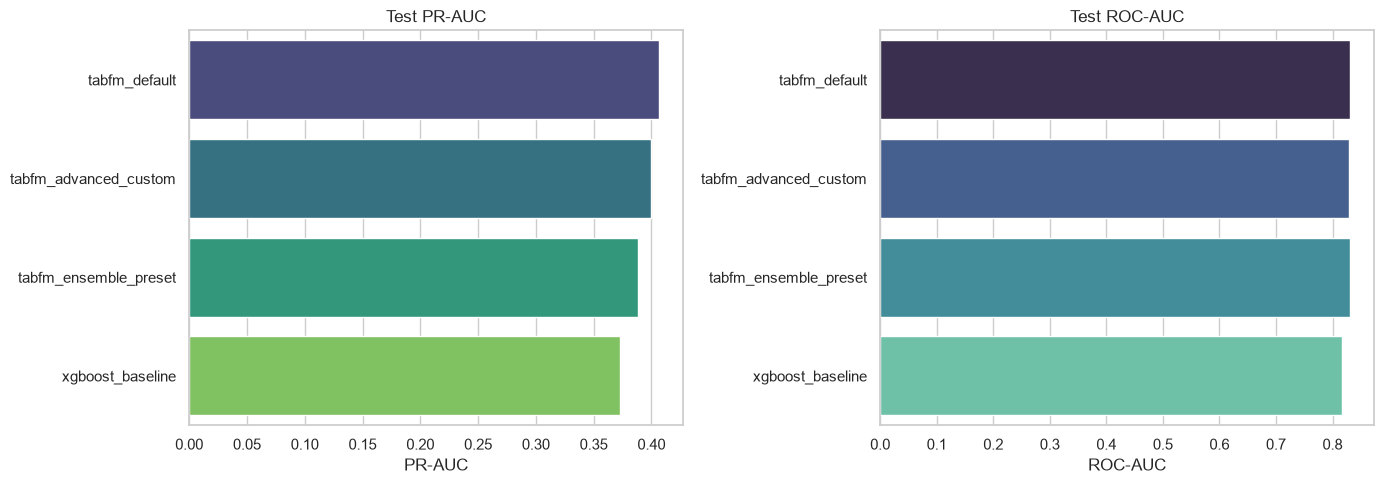

In [11]:
plot_df = metrics_df[metrics_df['split'] == 'test'].sort_values('pr_auc', ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=plot_df, x='pr_auc', y='model', ax=axes[0], palette='viridis')
axes[0].set_title('Test PR-AUC')
axes[0].set_xlabel('PR-AUC')
axes[0].set_ylabel('')

sns.barplot(data=plot_df, x='roc_auc', y='model', ax=axes[1], palette='mako')
axes[1].set_title('Test ROC-AUC')
axes[1].set_xlabel('ROC-AUC')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

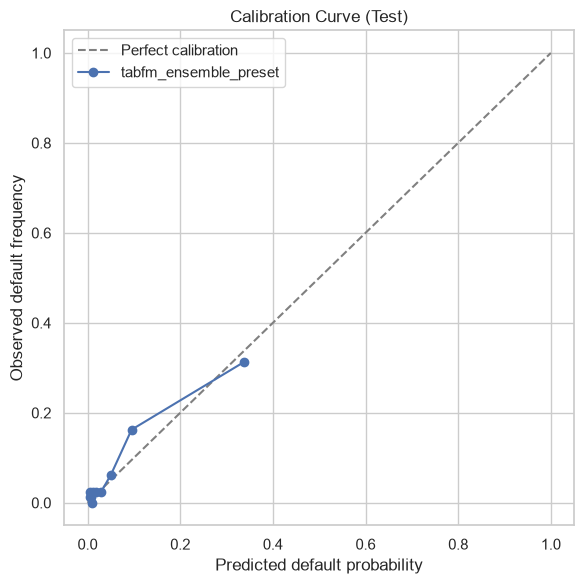

In [12]:
if len(champion_test_scores) != len(y_test_policy):
    raise ValueError(f'Champion score mismatch: len(scores)={len(champion_test_scores)} len(y_test_policy)={len(y_test_policy)}')

prob_true, prob_pred = calibration_curve(y_test_policy, champion_test_scores, n_bins=10, strategy='quantile')

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')
plt.plot(prob_pred, prob_true, marker='o', label=champion_model_name)
plt.title('Calibration Curve (Test)')
plt.xlabel('Predicted default probability')
plt.ylabel('Observed default frequency')
plt.legend()
plt.tight_layout()
plt.show()


## 10) Credit policy optimization (approve / review / decline)

We optimize threshold on validation data using simplified expected net value:

`net = margin_from_good_loans - default_losses - review_cost`

Assumptions are explicit and can be replaced with bank-specific economics.

In [13]:
def optimize_credit_threshold(
    y_true: np.ndarray,
    y_score: np.ndarray,
    exposure: np.ndarray,
    margin_rate: float,
    loss_given_default: float,
    review_cost: float,
    grid_size: int = 401,
) -> tuple[pd.DataFrame, dict[str, float]]:
    thresholds = np.linspace(0.0, 1.0, grid_size)
    rows: list[dict[str, float]] = []

    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    exposure = np.asarray(exposure).astype(float)

    for thr in thresholds:
        # approve if risk below threshold
        approved = (y_score < thr)

        approved_good = approved & (y_true == 0)
        approved_bad = approved & (y_true == 1)

        margin_value = float((exposure[approved_good] * margin_rate).sum())
        default_loss = float((exposure[approved_bad] * loss_given_default).sum())
        review_total_cost = float(approved.sum() * review_cost)
        net_value = margin_value - default_loss - review_total_cost

        rows.append({
            'threshold': float(thr),
            'approved_count': float(approved.sum()),
            'approved_good_count': float(approved_good.sum()),
            'approved_bad_count': float(approved_bad.sum()),
            'margin_value': margin_value,
            'default_loss': default_loss,
            'review_cost_total': review_total_cost,
            'expected_net_value': net_value,
        })

    curve = pd.DataFrame(rows)
    best_idx = int(curve['expected_net_value'].idxmax())
    return curve, curve.loc[best_idx].to_dict()


def make_exposure_proxy(meta: pd.DataFrame) -> np.ndarray:
    # Simple proxy: annualized income share, clipped to avoid extremes.
    income = pd.to_numeric(meta.get('MonthlyIncome', pd.Series(np.nan, index=meta.index)), errors='coerce')
    income = income.fillna(income.median())
    exposure = (income * 6.0).clip(lower=1000.0, upper=100000.0)
    return exposure.to_numpy(dtype=float)


BUSINESS_ASSUMPTIONS = {
    'margin_rate': 0.12,
    'loss_given_default': 0.55,
    'review_cost': 45.0,
}

val_exposure = make_exposure_proxy(val_meta_policy)
test_exposure = make_exposure_proxy(test_meta_policy)

threshold_curve_df, best_threshold_row = optimize_credit_threshold(
    y_true=y_val_policy,
    y_score=champion_val_scores,
    exposure=val_exposure,
    **BUSINESS_ASSUMPTIONS,
)
best_threshold = float(best_threshold_row['threshold'])
logger.info('Best approval threshold on validation: {:.3f}', best_threshold)

review_band = max(0.0, best_threshold - 0.10)

policy_df = test_meta_policy.copy()
policy_df['is_default'] = y_test_policy
policy_df['default_score'] = champion_test_scores
policy_df['credit_action'] = np.select(
    [
        policy_df['default_score'] >= best_threshold,
        policy_df['default_score'] >= review_band,
    ],
    ['decline', 'manual_review'],
    default='approve',
)

policy_summary = (
    policy_df.groupby('credit_action', dropna=False)
    .agg(
        applicants=('applicant_id', 'count'),
        default_rate=('is_default', 'mean'),
        avg_default_score=('default_score', 'mean'),
    )
    .reset_index()
    .sort_values('applicants', ascending=False)
)

policy_summary


2026-07-03 05:03:23.339 | INFO     | __main__:<module>:69 - Best approval threshold on validation: 0.185


,credit_action,applicants,default_rate,avg_default_score
0,approve,675,0.029630,0.019661
1,decline,68,0.338235,0.367047
2,manual_review,57,0.175439,0.123059


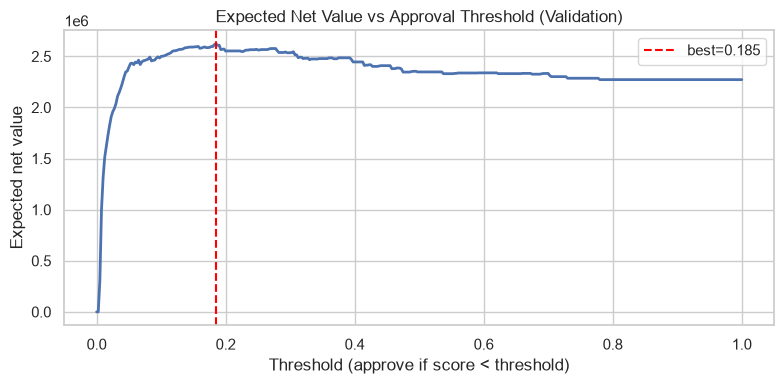

In [14]:
plt.figure(figsize=(8, 4))
sns.lineplot(data=threshold_curve_df, x='threshold', y='expected_net_value', linewidth=2)
plt.axvline(best_threshold, color='red', linestyle='--', label=f'best={best_threshold:.3f}')
plt.title('Expected Net Value vs Approval Threshold (Validation)')
plt.xlabel('Threshold (approve if score < threshold)')
plt.ylabel('Expected net value')
plt.legend()
plt.tight_layout()
plt.show()

## 11) Persist artifacts

In [15]:
metrics_path = ARTIFACT_DIR / 'problem7_loan_model_metrics.csv'
pred_path = ARTIFACT_DIR / 'problem7_loan_predictions_test.parquet'
policy_path = ARTIFACT_DIR / 'problem7_loan_credit_actions.csv'
policy_summary_path = ARTIFACT_DIR / 'problem7_loan_policy_summary.csv'
threshold_curve_path = ARTIFACT_DIR / 'problem7_loan_threshold_curve.csv'
threshold_summary_path = ARTIFACT_DIR / 'problem7_loan_threshold_summary.csv'
runtime_meta_path = ARTIFACT_DIR / 'problem7_loan_runtime_meta.json'

prediction_frame = policy_df[[
    'applicant_id',
    'is_default',
    'default_score',
    'credit_action',
]].copy()

metrics_df.to_csv(metrics_path, index=False)
policy_df.to_csv(policy_path, index=False)
policy_summary.to_csv(policy_summary_path, index=False)
threshold_curve_df.to_csv(threshold_curve_path, index=False)

threshold_summary_df = pd.DataFrame([
    {'split': 'validation', **best_threshold_row},
    {
        'split': 'test',
        **optimize_credit_threshold(
            y_true=y_test_policy,
            y_score=champion_test_scores,
            exposure=test_exposure,
            **BUSINESS_ASSUMPTIONS,
        )[1],
    },
])
threshold_summary_df.to_csv(threshold_summary_path, index=False)

pred_cast = prediction_frame.copy()
pred_cast['applicant_id'] = pred_cast['applicant_id'].astype('int64')
pred_cast['is_default'] = pred_cast['is_default'].astype('int32')
pred_cast['default_score'] = pred_cast['default_score'].astype('float64')
pred_cast['credit_action'] = pred_cast['credit_action'].astype(str)

pl.DataFrame({col: pred_cast[col].tolist() for col in pred_cast.columns}).write_parquet(pred_path)

runtime_meta = {
    'seed': SEED,
    'openml_data_id': OPENML_DATA_ID,
    'sample_train_rows': int(SAMPLE_TRAIN_ROWS),
    'sample_eval_rows': int(SAMPLE_EVAL_ROWS),
    'tabfm_context_max_rows': int(TABFM_CONTEXT_MAX_ROWS),
    'tabfm_eval_max_rows': int(TABFM_EVAL_MAX_ROWS),
    'tabfm_fast_mode': bool(TABFM_FAST_MODE),
    'tabfm_device_preference': TABFM_DEVICE_PREF,
    'tabfm_device_effective': DEVICE,
    'tabfm_checkpoint_override': str(TABFM_CKPT_PATH) if TABFM_CKPT_PATH else None,
    'champion_model': champion_model_name,
    'best_threshold': best_threshold,
    'business_assumptions': BUSINESS_ASSUMPTIONS,
    'policy_rows_val': int(len(y_val_policy)),
    'policy_rows_test': int(len(y_test_policy)),
}
runtime_meta_path.write_text(json.dumps(runtime_meta, indent=2))

for path in [
    metrics_path,
    pred_path,
    policy_path,
    policy_summary_path,
    threshold_curve_path,
    threshold_summary_path,
    runtime_meta_path,
]:
    logger.info('Wrote {}', path)

sorted(p.name for p in ARTIFACT_DIR.glob('problem7_loan_*'))

2026-07-03 05:03:23.483 | INFO     | __main__:<module>:71 - Wrote /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem7_loan_default_prediction/artifacts/problem7_loan_model_metrics.csv


2026-07-03 05:03:23.483 | INFO     | __main__:<module>:71 - Wrote /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem7_loan_default_prediction/artifacts/problem7_loan_predictions_test.parquet


2026-07-03 05:03:23.484 | INFO     | __main__:<module>:71 - Wrote /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem7_loan_default_prediction/artifacts/problem7_loan_credit_actions.csv


2026-07-03 05:03:23.484 | INFO     | __main__:<module>:71 - Wrote /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem7_loan_default_prediction/artifacts/problem7_loan_policy_summary.csv


2026-07-03 05:03:23.484 | INFO     | __main__:<module>:71 - Wrote /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem7_loan_default_prediction/artifacts/problem7_loan_threshold_curve.csv


2026-07-03 05:03:23.484 | INFO     | __main__:<module>:71 - Wrote /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem7_loan_default_prediction/artifacts/problem7_loan_threshold_summary.csv


2026-07-03 05:03:23.485 | INFO     | __main__:<module>:71 - Wrote /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem7_loan_default_prediction/artifacts/problem7_loan_runtime_meta.json


['problem7_loan_credit_actions.csv',
 'problem7_loan_model_metrics.csv',
 'problem7_loan_policy_summary.csv',
 'problem7_loan_predictions_test.parquet',
 'problem7_loan_runtime_meta.json',
 'problem7_loan_threshold_curve.csv',
 'problem7_loan_threshold_summary.csv']

## 12) Deployment notes

Recommended next steps:
1. Replace exposure proxy with actual loan amount / tenor / pricing fields.
2. Add reject-inference strategy to reduce approval-bias drift.
3. Calibrate thresholds by product segment and macro regime.
4. Add adverse-action explainability outputs for compliance.